In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, IsolationForest
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import train_test_split, GridSearchCV, LeaveOneOut
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                           mean_absolute_error, precision_recall_curve, roc_curve, auc)
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import AgglomerativeClustering
from sklearn.manifold import TSNE
from xgboost import XGBClassifier, XGBRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.cluster import KMeans
from sklearn.feature_selection import mutual_info_classif
import xgboost as xgb
from sklearn.feature_selection import SelectFromModel

import shap
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [107]:
# Load and clean data
data = pd.read_csv('wedowind.csv')
data.drop('Unnamed: 0', axis=1, inplace=True)
data['timestamp'] = pd.to_datetime(data['timestamp'])
data = data[(data['power'] > 0) & (data['rotor_speed'] > 0)]


In [108]:
# Feature engineering
def create_features(df):
    # Temporal features
    df['hour'] = df['timestamp'].dt.hour
    df['day_of_week'] = df['timestamp'].dt.dayofweek

    # Rolling statistics
    for col in ['wind_speed', 'power', 'bearing_temperature']:
        df[f'{col}_rolling_avg_6h'] = df.groupby('plant_name')[col].transform(
            lambda x: x.rolling(6, min_periods=1).mean())
        df[f'{col}_rolling_std_6h'] = df.groupby('plant_name')[col].transform(
            lambda x: x.rolling(6, min_periods=1).std())

    # Equipment stress indicators
    df['power_per_rpm'] = df['power'] / (df['rotor_speed'] + 0.001)
    return df

data = create_features(data)

In [110]:
# Prepare features for clustering
features = data.drop(['timestamp', 'plant_name', 'errorcode'], axis=1)

# Handle missing values - two options:

# Option 1: Drop rows with any missing values (if few missing values)
data_cleaned = data.dropna().copy()
features_cleaned = features.dropna().copy()

# Verify no missing values remain
print(f"Remaining missing values: {features_cleaned.isna().sum().sum()}")

Remaining missing values: 0


In [111]:
# Scale features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_cleaned)

Reduced to 13 principal components
Explained variance ratio: 0.95


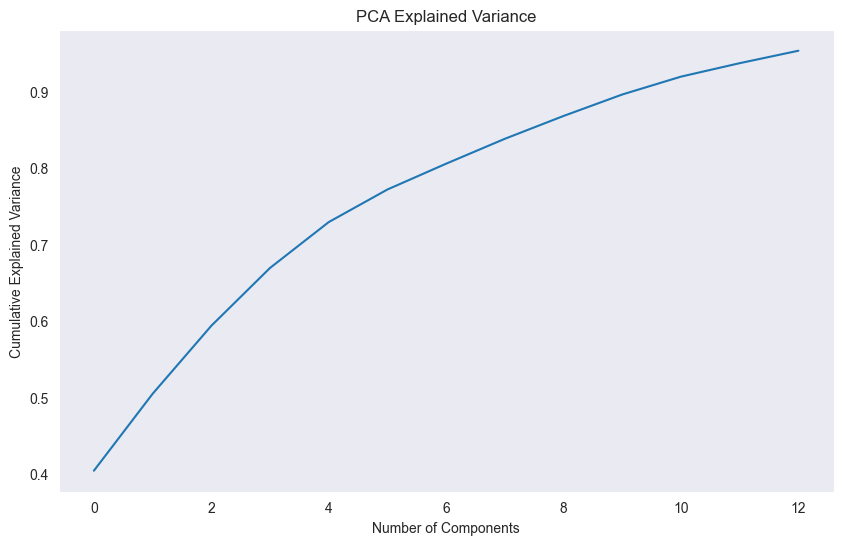

In [112]:
pca = PCA(n_components=0.95)
principal_components = pca.fit_transform(scaled_features)
print(f"Reduced to {principal_components.shape[1]} principal components")
print(f"Explained variance ratio: {pca.explained_variance_ratio_.sum():.2f}")

# Plot explained variance
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid()
plt.show()

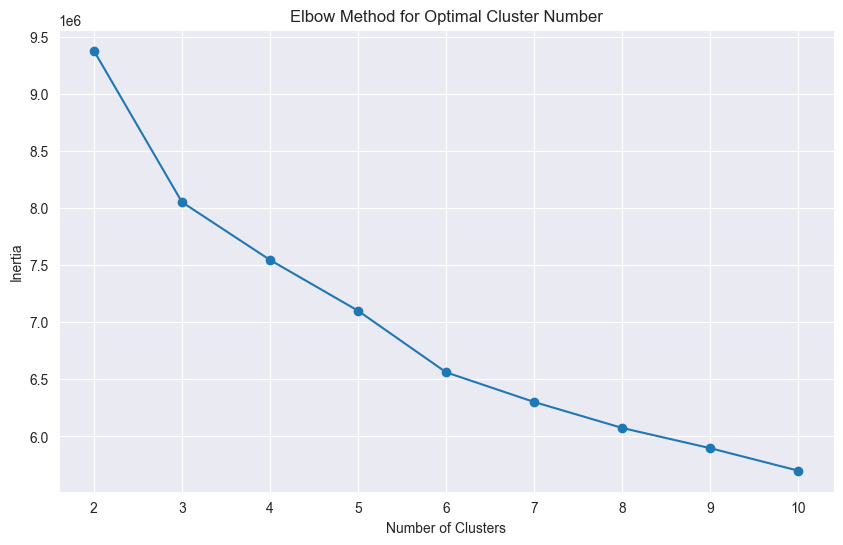

In [113]:
# Determine optimal number of clusters
inertia = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(principal_components)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), inertia, marker='o')
plt.title('Elbow Method for Optimal Cluster Number')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()


In [114]:
# Fit with optimal clusters (using 5 as in your original code)
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(principal_components)
data_cleaned['cluster'] = clusters


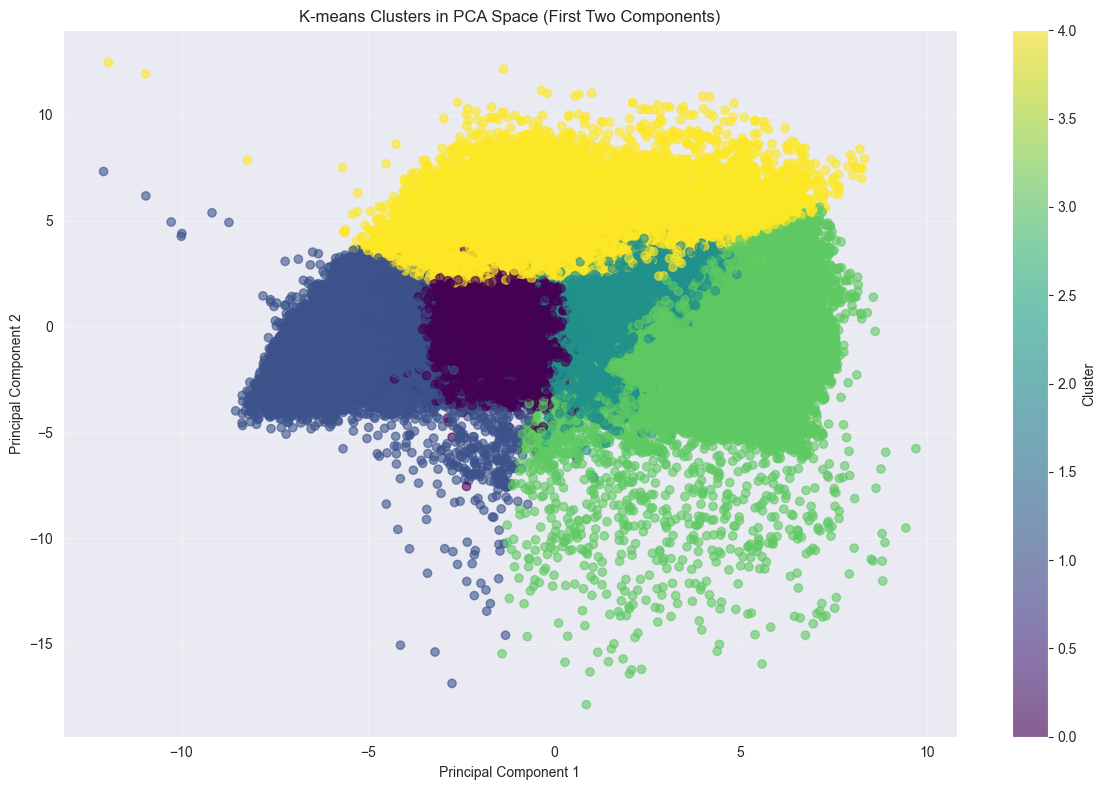


Cluster Analysis Complete
Cluster distribution:
cluster
0    132407
2    120812
3    103169
1     90070
4     23990
Name: count, dtype: int64


In [115]:
# Visualize clusters in PCA space
plt.figure(figsize=(12, 8))
scatter = plt.scatter(principal_components[:, 0],
                     principal_components[:, 1],
                     c=clusters, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.title('K-means Clusters in PCA Space (First Two Components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nCluster Analysis Complete")
print(f"Cluster distribution:\n{data_cleaned['cluster'].value_counts()}")

In [174]:
# First create binary failure indicator
data_cleaned['failure'] = (data_cleaned['errorcode'] != 0).astype(int)

# Your exact TTF calculation function
def create_ttf_feature(group):
    """Create Time-to-Failure feature following paper's exact methodology"""
    group = group.sort_values('timestamp')
    group['ttf'] = 0.0

    failure_indices = group.index[group['failure'] == 1].tolist()

    # Calculate time until next failure for each point
    for i in range(len(group)):
        current_time = group.iloc[i]['timestamp']
        future_failures = group[(group['timestamp'] > current_time) & (group['failure'] == 1)]

        if not future_failures.empty:
            next_failure_time = future_failures.iloc[0]['timestamp']
            ttf_hours = (next_failure_time - current_time).total_seconds() / 3600
            group.loc[group.index[i], 'ttf'] = ttf_hours
        else:
            # No future failures in this turbine's data
            group.loc[group.index[i], 'ttf'] = np.nan

    return group


In [175]:
# Apply TTF creation to each turbine separately
data_ttf = data_cleaned.groupby('plant_name', group_keys=False).apply(create_ttf_feature)

# Clean and filter data as specified in paper
data_ttf = data_ttf.dropna(subset=['ttf'])  # Remove unknown TTF
data_ttf = data_ttf[(data_ttf['ttf'] <= 15) & (data_ttf['ttf'] > 0)]  # Last 15h before failure
data_ttf = data_ttf[data_ttf['failure'] == 0]  # Remove actual failure points

In [178]:
print(f"\nTTF Dataset Prepared: {len(data_ttf)} records")
print(f"Time-to-Failure range: {data_ttf['ttf'].min():.1f} to {data_ttf['ttf'].max():.1f} hours")


TTF Dataset Prepared: 61210 records
Time-to-Failure range: 0.2 to 15.0 hours


In [179]:
selected_features = [f for f in selected_features if f in data_ttf.columns]


In [180]:
# Prepare features and target using selected features from clustering
X = data_ttf[selected_features]
y = data_ttf['ttf']
groups = data_ttf['plant_name']

# Leave-One-Turbine-Out cross validation
logo = LeaveOneGroupOut()
mae_results = {}
predictions = {}

In [181]:
for train_index, test_index in logo.split(X, y, groups):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    turbine_id = groups.iloc[test_index[0]]

    # Train XGBoost model with your parameters
    model = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=300,
        max_depth=None,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mae_results[turbine_id] = mae

    # Store predictions for analysis
    predictions[turbine_id] = {
        'actual': y_test.values,
        'predicted': y_pred,
        'timestamps': data_ttf.iloc[test_index]['timestamp'].values,
        'features': X_test.values
    }

In [182]:
# MAE results
print("\nMAE Results by Turbine (hours):")
print("Turbine ID | MAE (h) | Records")
print("-----------------------------")
for turbine_id, mae in sorted(mae_results.items()):
    rec_count = len(predictions[turbine_id]['actual'])
    print(f"{turbine_id:9} | {mae:.2f} | {rec_count:7}")



MAE Results by Turbine (hours):
Turbine ID | MAE (h) | Records
-----------------------------
      109 | 3.23 |    9854
      114 | 2.71 |    9403
      115 | 3.25 |   16089
      116 | 3.40 |   15681
      120 | 2.90 |   10183


In [183]:
# Plot function for specific turbines
def plot_ttf_comparison(turbine_id, predictions):
    if turbine_id not in predictions:
        print(f"No data for turbine {turbine_id}")
        return

    data = predictions[turbine_id]
    obs_numbers = np.arange(len(data['timestamps']))

    plt.figure(figsize=(14, 6))
    plt.plot(obs_numbers, data['actual'], label='Actual TTF', color='blue', linewidth=1.5)
    plt.plot(obs_numbers, data['predicted'], label='Predicted TTF', color='orange', linestyle='--', linewidth=1.5)

    # Highlight ranges as in paper
    plt.axvspan(5000, 5400, alpha=0.1, color='green', label='Good prediction range')
    plt.axvspan(5400, 5700, alpha=0.1, color='red', label='Poor prediction range')

    plt.title(f"Actual vs Predicted Time-to-Failure for Turbine #{turbine_id}\nMAE: {mae_results[turbine_id]:.2f} hours", pad=20)
    plt.xlabel("Observation Number")
    plt.ylabel("Time to Failure (hours)")
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)

    if len(obs_numbers) > 5700:
        plt.xlim(4500, 6000)

    plt.tight_layout()
    plt.show()


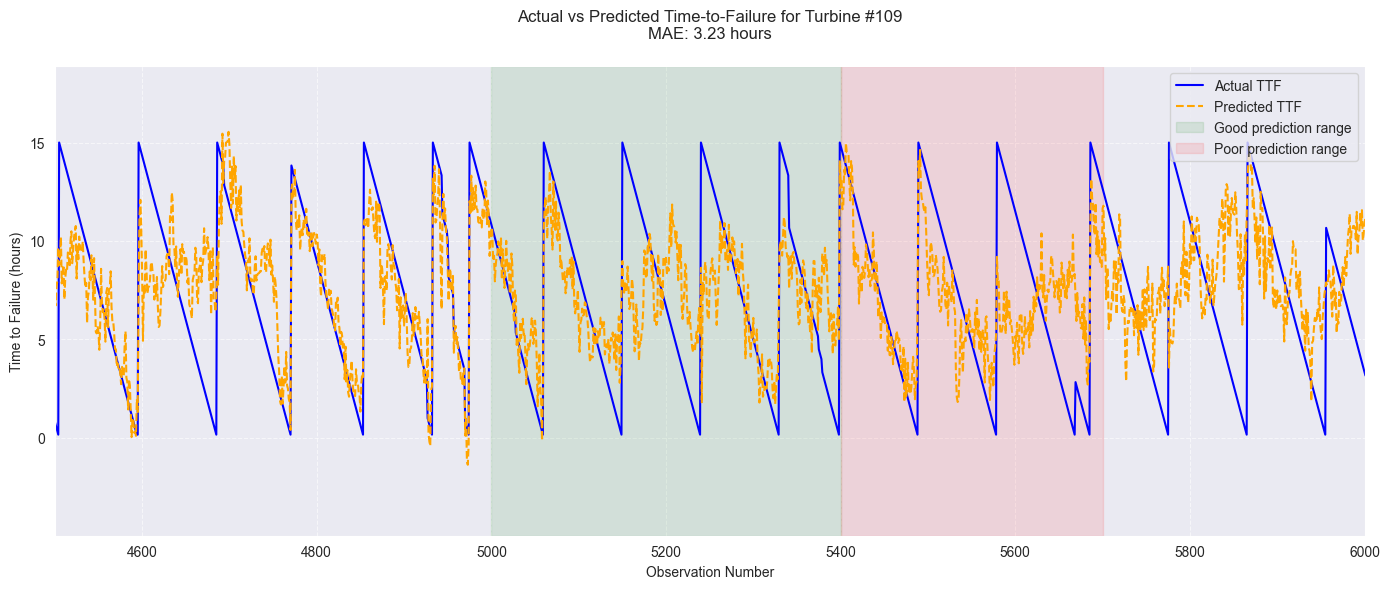

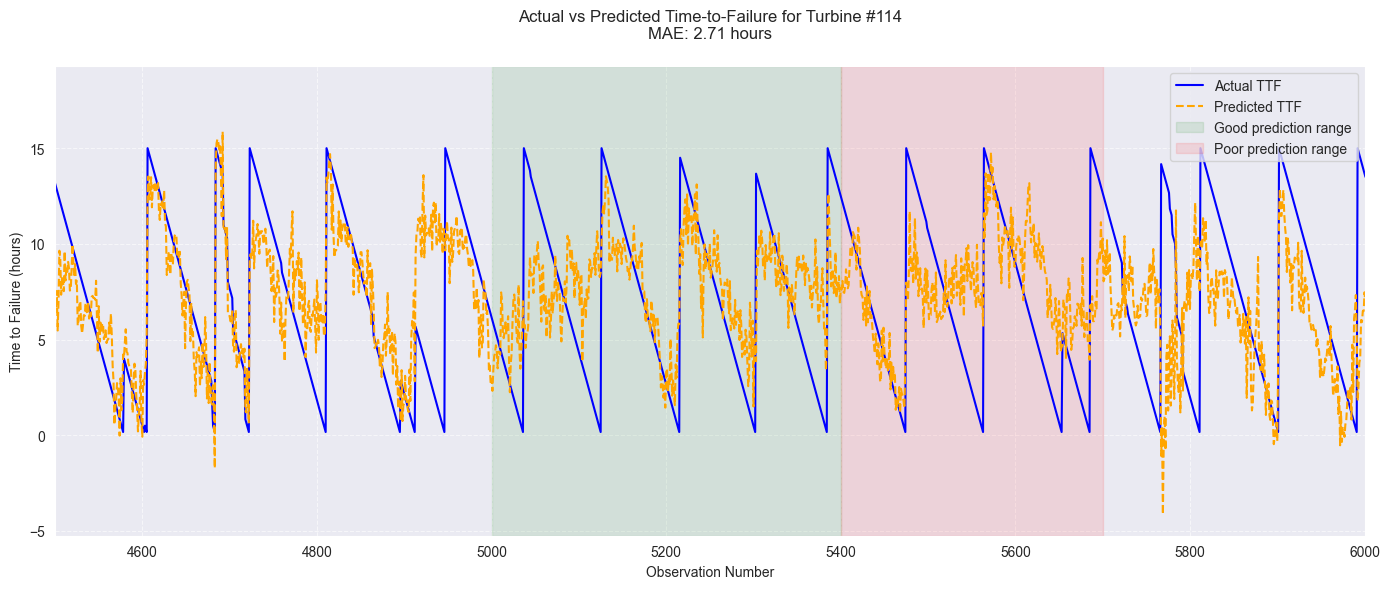

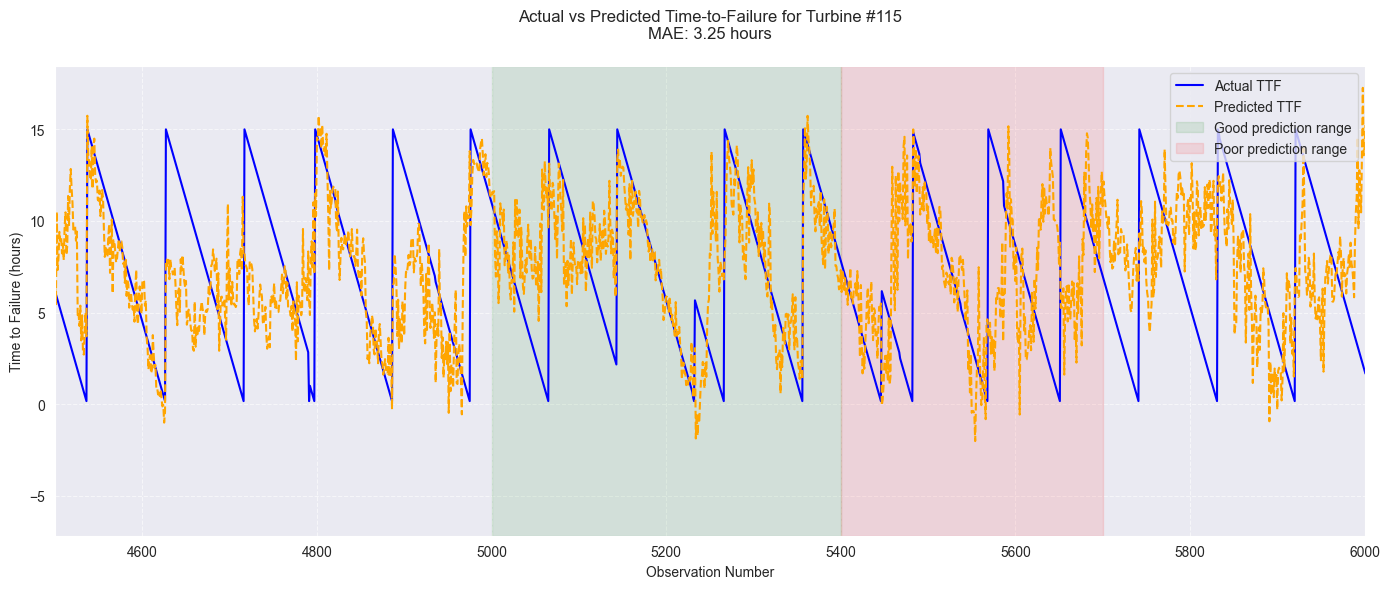

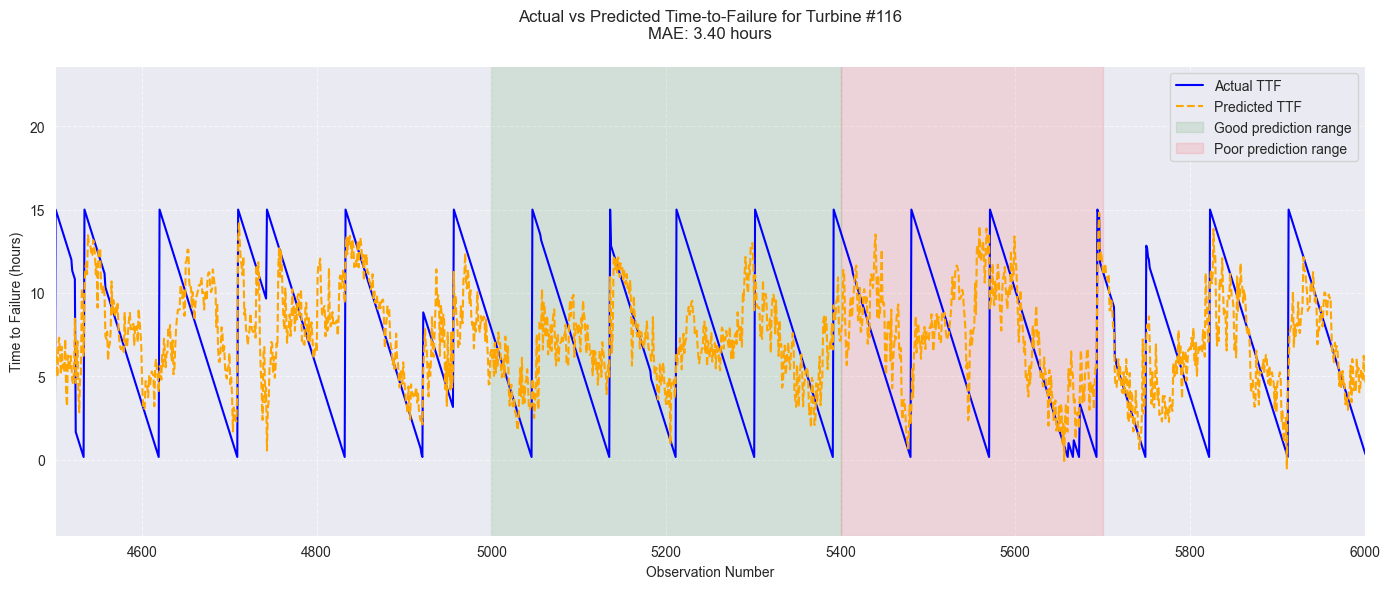

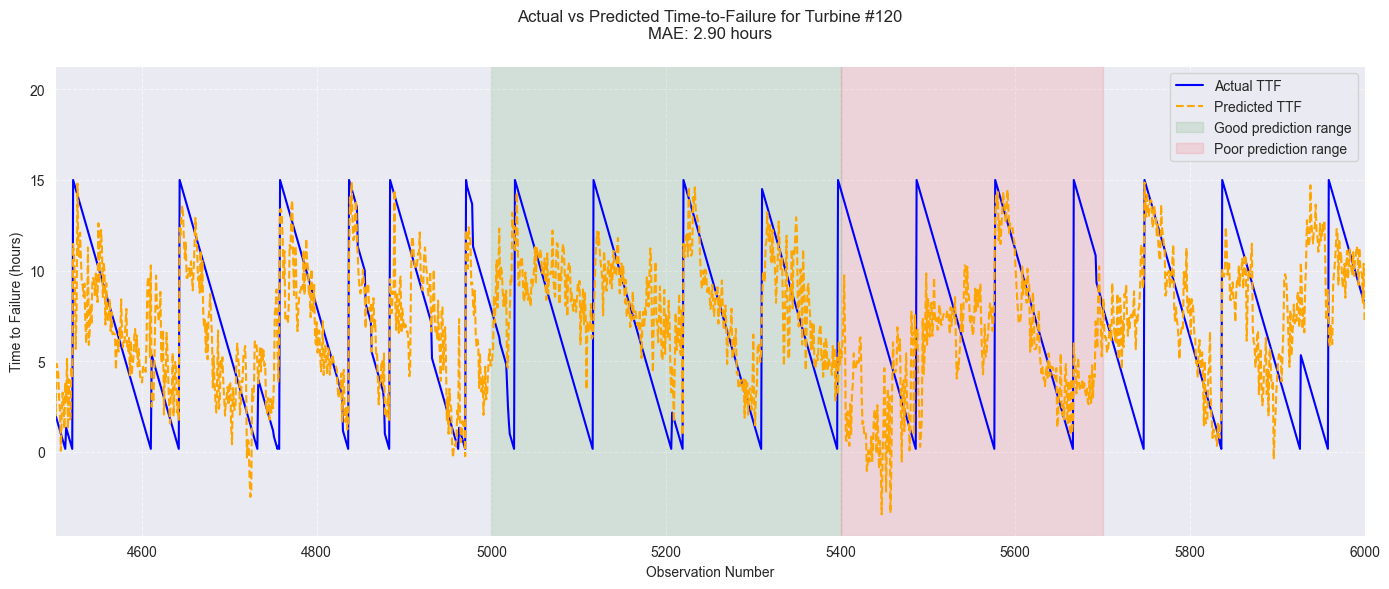


Generating SHAP explanations...


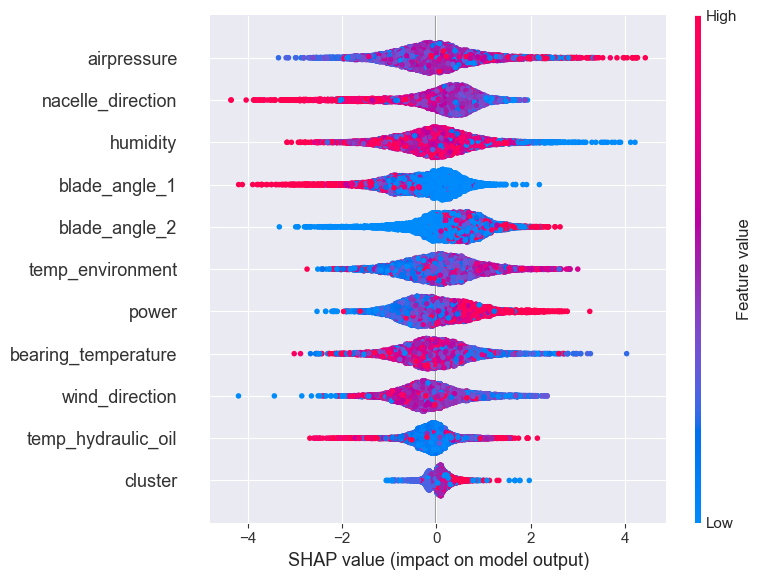

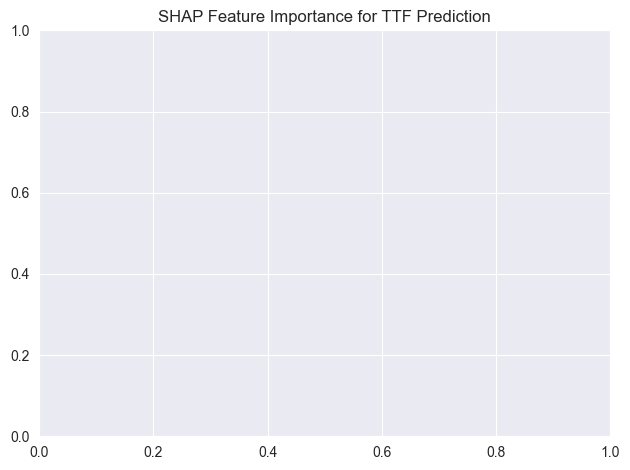

In [184]:
# Generate plots for all turbines
for turbine_id in predictions.keys():
    plot_ttf_comparison(turbine_id, predictions)

# SHAP analysis for the last trained model
print("\nGenerating SHAP explanations...")
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# Summary plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, feature_names=selected_features)
plt.title("SHAP Feature Importance for TTF Prediction")
plt.tight_layout()
plt.savefig('shap_feature_importance.png', dpi=300)
plt.show()